In [15]:
!pip install category_encoders shap yellowbrick

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
import shap
import category_encoders as ce

from scipy import stats
from scipy.stats import skew, boxcox
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV, ElasticNet, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from yellowbrick.regressor import ResidualsPlot, PredictionError
from category_encoders import TargetEncoder
from ipywidgets import interact

warnings.filterwarnings("ignore")

In [17]:
# Forma 2)

# Reemplaza con el ID real de tu archivo en Drive
file_id = '1tDOjLZne6NC5g0IlCpw3kB1BHHHW8X9A'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Cargar el dataset
df = pd.read_csv(url)
df

#https://drive.google.com/file/d/1tDOjLZne6NC5g0IlCpw3kB1BHHHW8X9A/view?usp=sharing

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,Male,7.23,8.78,6.96,91.44,FPS,3.25,9.36,235.84,14.69,Low,86.459555
1,2,19,Male,0.07,8.72,7.63,63.63,Casual,1.02,3.21,328.71,2.47,Medium,98.230000
2,3,23,Female,1.73,9.56,4.40,83.26,Casual,3.46,5.56,313.61,4.73,High,90.560000
3,4,20,Female,6.62,1.68,7.83,75.04,RPG,1.46,11.78,241.84,14.54,Low,32.670000
4,5,22,Female,5.36,5.83,5.55,65.57,FPS,1.01,8.23,249.31,12.48,Low,58.710000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,24,Male,6.33,5.09,4.83,63.74,FPS,4.11,9.96,231.33,11.14,Low,35.110000
7996,7997,22,Female,5.77,6.09,6.23,84.37,FPS,3.42,11.19,254.13,10.66,Low,60.800000
7997,7998,20,Male,2.87,8.51,8.62,67.30,FPS,2.36,6.40,305.00,6.42,Medium,90.280000
7998,7999,22,Female,0.98,2.99,7.29,61.13,FPS,2.02,4.57,325.36,2.14,Medium,56.330000


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_id        8000 non-null   int64  
 1   age               8000 non-null   int64  
 2   gender            8000 non-null   object 
 3   gaming_hours      8000 non-null   float64
 4   study_hours       8000 non-null   float64
 5   sleep_hours       8000 non-null   float64
 6   attendance        8000 non-null   float64
 7   gaming_genre      8000 non-null   object 
 8   social_activity   8000 non-null   float64
 9   device_usage      8000 non-null   float64
 10  reaction_time_ms  8000 non-null   float64
 11  addiction_score   8000 non-null   float64
 12  stress_level      8000 non-null   object 
 13  grades            8000 non-null   float64
dtypes: float64(9), int64(2), object(3)
memory usage: 875.1+ KB


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,8000.0,4000.500000,2309.545410,1.00,2000.750000,4000.500,6000.250000,8000.000000
age,8000.0,19.983625,2.587072,16.00,18.000000,20.000,22.000000,24.000000
gaming_hours,8000.0,4.085773,2.308801,0.00,2.130000,4.130,6.060000,8.000000
study_hours,8000.0,5.460581,2.575787,1.00,3.240000,5.460,7.660000,10.000000
sleep_hours,8000.0,6.493453,1.442656,4.00,5.240000,6.505,7.730000,9.000000
attendance,8000.0,79.886525,11.580419,60.00,69.780000,79.695,90.100000,100.000000
social_activity,8000.0,2.507790,1.441128,0.00,1.287500,2.500,3.760000,5.000000
device_usage,8000.0,7.586315,2.710035,1.10,5.560000,7.610,9.600000,13.950000
reaction_time_ms,8000.0,271.105839,29.440675,183.26,247.160000,270.475,294.690000,347.870000
addiction_score,8000.0,9.908492,5.035837,-4.51,5.920000,10.005,13.860000,23.160000


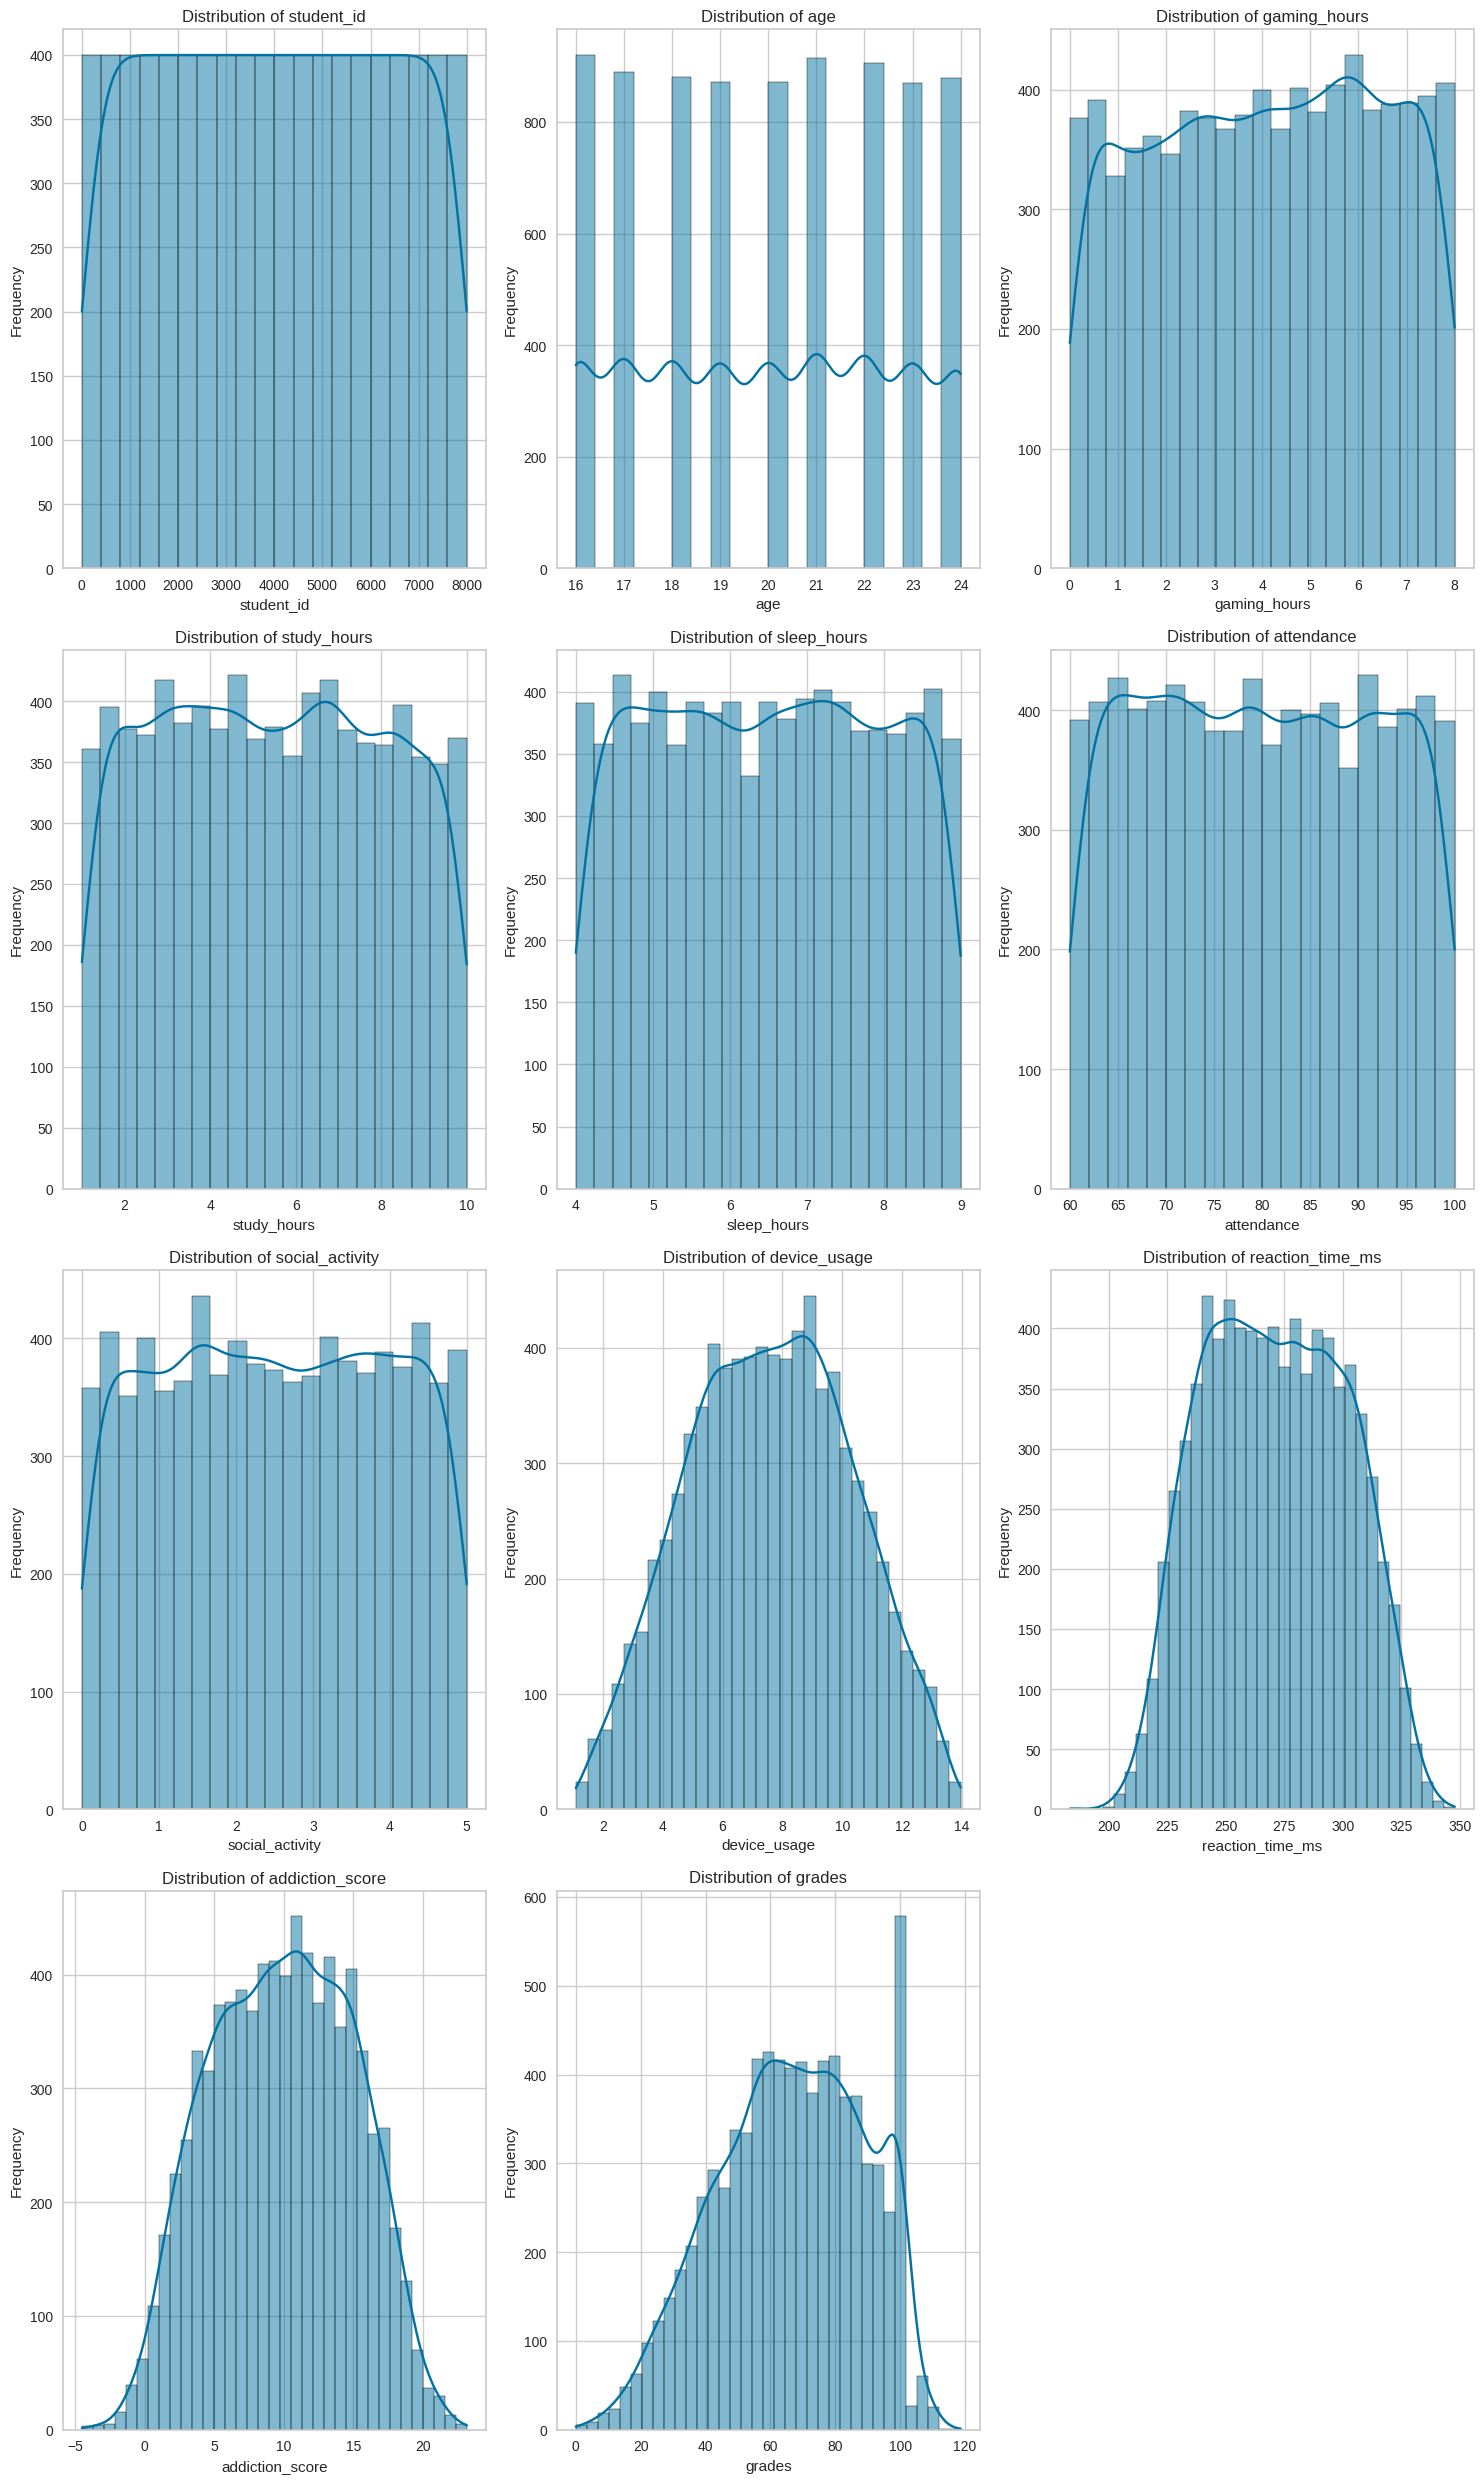

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reemplaza con el ID real de tu archivo en Drive
file_id = '1tDOjLZne6NC5g0IlCpw3kB1BHHHW8X9A'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

# Cargar el dataset
df = pd.read_csv(url)

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 25))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

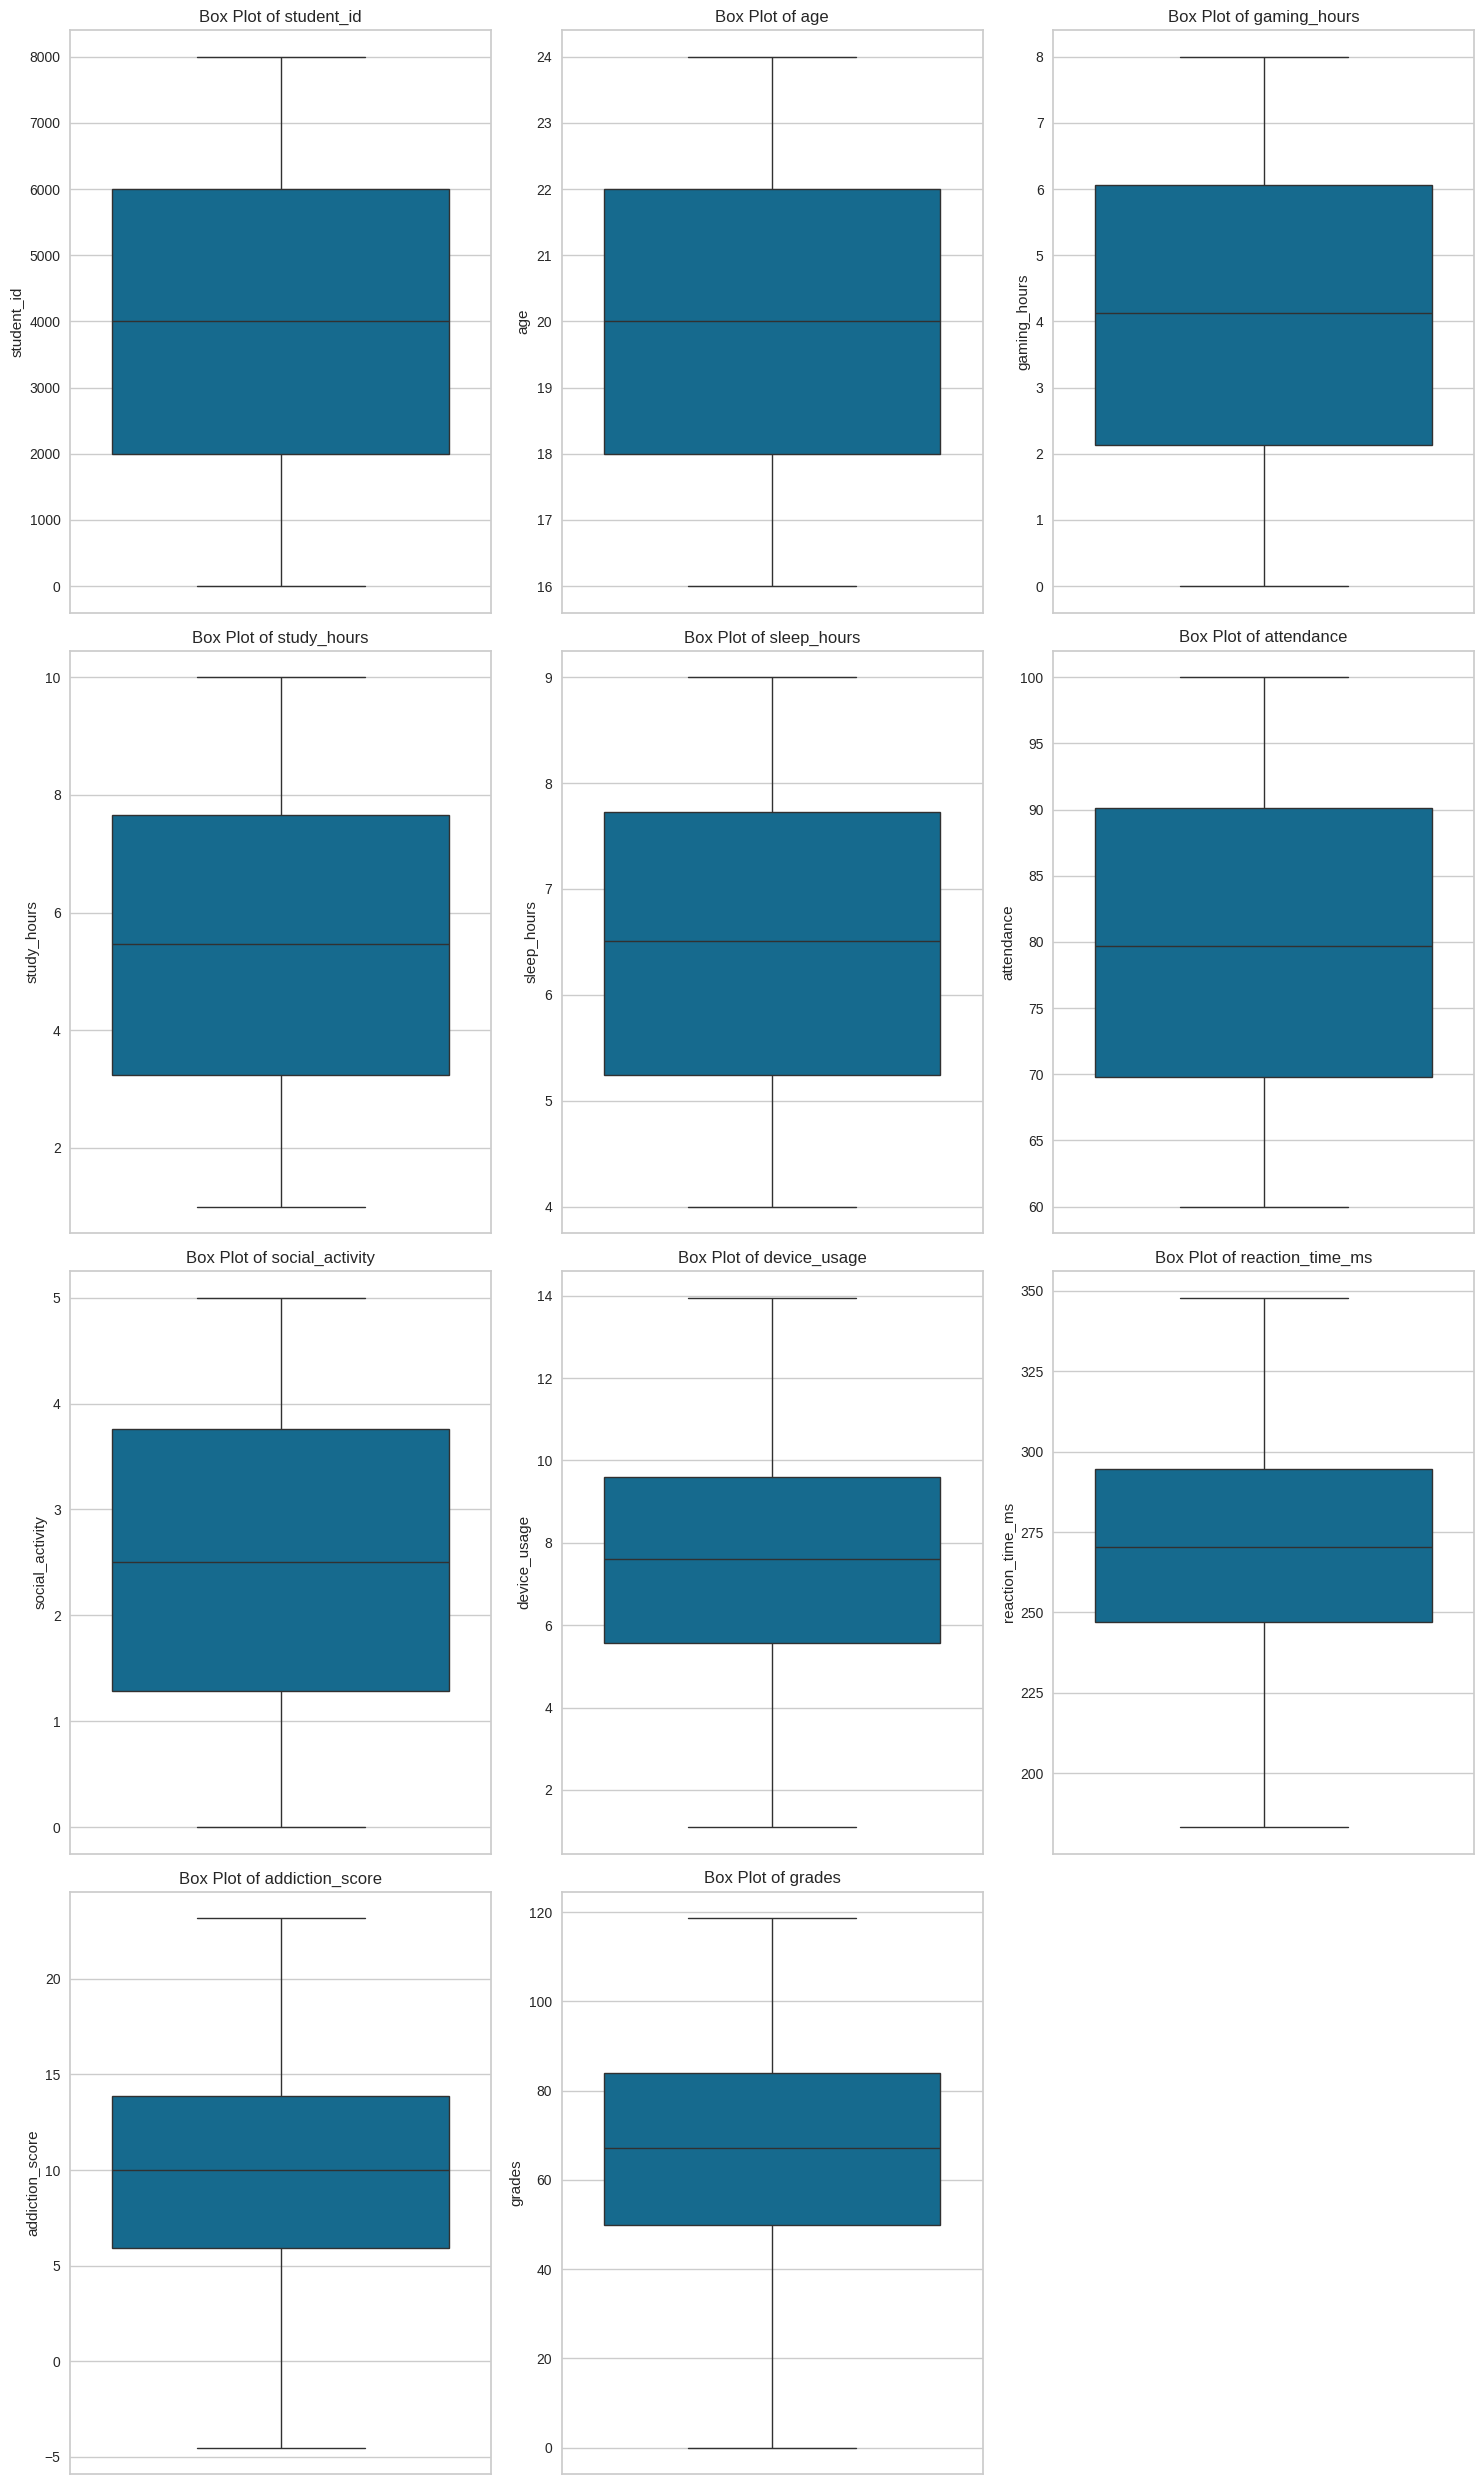

In [21]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 25))
for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

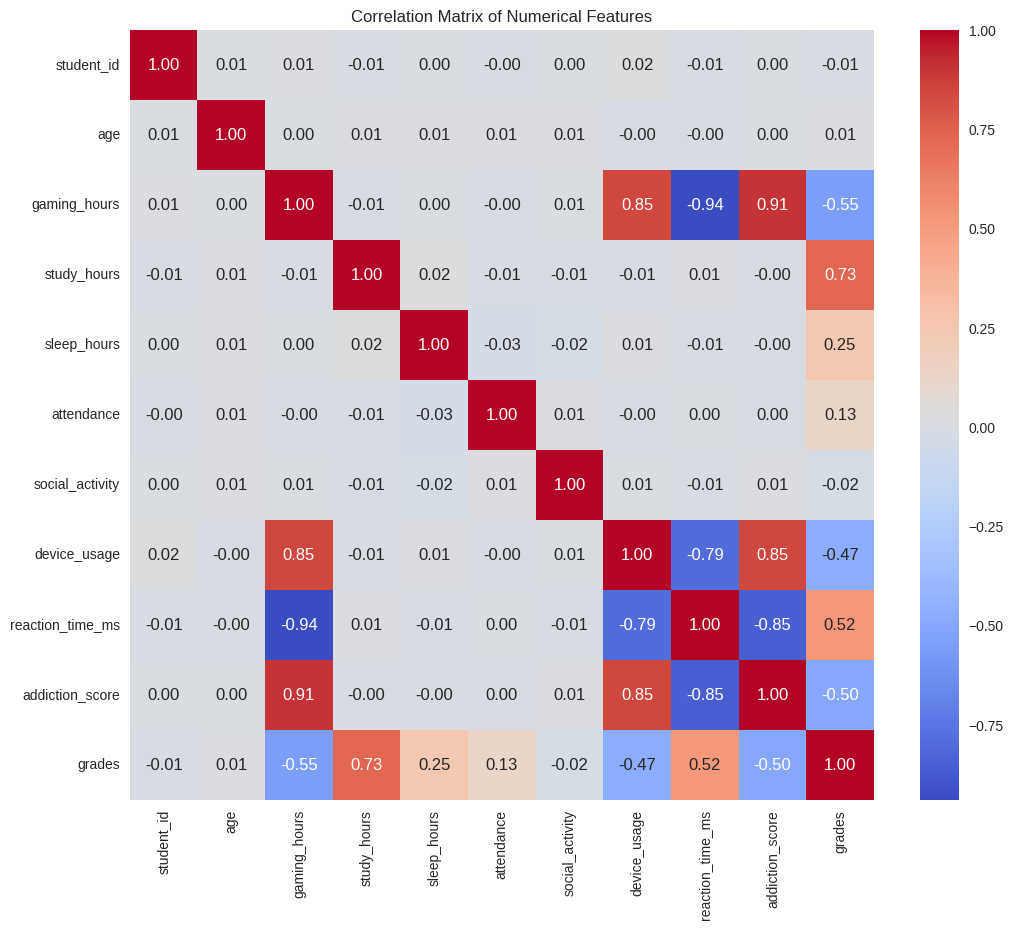

In [22]:
correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [23]:
# Identificar columnas categóricas
categorical_cols = ['gender', 'gaming_genre', 'stress_level']
target_col = 'grades'

# 1. Label Encoding
df_label = df.copy()
le = LabelEncoder()
for col in categorical_cols:
    df_label[col] = le.fit_transform(df_label[col].astype(str))

# 2. One-Hot Encoding
df_onehot = pd.get_dummies(df, columns=categorical_cols, prefix=categorical_cols)

# 3. Target Encoding
te = TargetEncoder(cols=categorical_cols)
df_target = te.fit_transform(df, df[target_col])

print("Codificaciones completadas. Dataframes creados: df_label, df_onehot, df_target.")
print("\n--- Vista previa de One-Hot Encoding ---")
display(df_onehot.head())

Codificaciones completadas. Dataframes creados: df_label, df_onehot, df_target.

--- Vista previa de One-Hot Encoding ---


,student_id,age,gaming_hours,study_hours,sleep_hours,attendance,social_activity,device_usage,reaction_time_ms,addiction_score,grades,gender_Female,gender_Male,gender_Other,gaming_genre_Casual,gaming_genre_FPS,gaming_genre_RPG,stress_level_High,stress_level_Low,stress_level_Medium
0,1,22,7.23,8.78,6.96,91.44,3.25,9.36,235.84,14.69,86.459555,False,True,False,False,True,False,False,True,False
1,2,19,0.07,8.72,7.63,63.63,1.02,3.21,328.71,2.47,98.230000,False,True,False,True,False,False,False,False,True
2,3,23,1.73,9.56,4.40,83.26,3.46,5.56,313.61,4.73,90.560000,True,False,False,True,False,False,True,False,False
3,4,20,6.62,1.68,7.83,75.04,1.46,11.78,241.84,14.54,32.670000,True,False,False,False,False,True,False,True,False
4,5,22,5.36,5.83,5.55,65.57,1.01,8.23,249.31,12.48,58.710000,True,False,False,False,True,False,False,True,False


### ¿Cuál es el mejor método para este dataset?

Para este dataset específico, el **Target Encoding** o el **One-Hot Encoding** suelen ser las mejores opciones, dependiendo del modelo que utilices:

1.  **One-Hot Encoding**: Es ideal para variables con baja cardinalidad como `gender` (Male/Female) y `stress_level` (Low/Medium/High). No asume un orden intrínseco, lo cual es correcto para el género y el género de juego.
2.  **Target Encoding**: Es muy potente si planeas usar modelos de ensamble (como Random Forest o XGBoost), ya que captura la relación directa entre la categoría y la variable objetivo (`grades`). Sin embargo, hay que tener cuidado con el sobreajuste (overfitting).
3.  **Label Encoding**: Generalmente **no es recomendable** para estas columnas, ya que asigna números arbitrarios (0, 1, 2...) que los modelos lineales pueden interpretar erróneamente como una jerarquía o importancia (por ejemplo, pensar que 'FPS' es 'mayor' que 'Casual' solo por el número asignado).

**Conclusión**: Si buscas simplicidad y vas a usar una regresión lineal, usa **One-Hot Encoding**. Si buscas el máximo rendimiento predictivo con modelos complejos, **Target Encoding** es la mejor opción.

In [24]:
df_target

,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,22,65.857692,7.23,8.78,6.96,91.44,66.150053,3.25,9.36,235.84,14.69,50.573928,86.459555
1,2,19,65.857692,0.07,8.72,7.63,63.63,66.439080,1.02,3.21,328.71,2.47,72.731780,98.230000
2,3,23,66.579074,1.73,9.56,4.40,83.26,66.439080,3.46,5.56,313.61,4.73,81.019857,90.560000
3,4,20,66.579074,6.62,1.68,7.83,75.04,65.963455,1.46,11.78,241.84,14.54,50.573928,32.670000
4,5,22,66.579074,5.36,5.83,5.55,65.57,66.150053,1.01,8.23,249.31,12.48,50.573928,58.710000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,24,65.857692,6.33,5.09,4.83,63.74,66.150053,4.11,9.96,231.33,11.14,50.573928,35.110000
7996,7997,22,66.579074,5.77,6.09,6.23,84.37,66.150053,3.42,11.19,254.13,10.66,50.573928,60.800000
7997,7998,20,65.857692,2.87,8.51,8.62,67.30,66.150053,2.36,6.40,305.00,6.42,72.731780,90.280000
7998,7999,22,66.579074,0.98,2.99,7.29,61.13,66.150053,2.02,4.57,325.36,2.14,72.731780,56.330000


In [25]:
# 1. Seleccionar columnas para escalar (excluyendo el ID y el target)
columns_to_scale = df_target.select_dtypes(include=['float64', 'int64']).columns.drop(['student_id', 'grades'])

# 2. Inicializar el escalador (StandardScaler para normalización z-score)
scaler = StandardScaler()

# 3. Aplicar el escalamiento
df_scaled = df_target.copy()
df_scaled[columns_to_scale] = scaler.fit_transform(df_target[columns_to_scale])

# Mostrar el resultado
print("Dataset 'df_target' escalado exitosamente (almacenado en 'df_scaled')")
display(df_scaled.head())

Dataset 'df_target' escalado exitosamente (almacenado en 'df_scaled')


,student_id,age,gender,gaming_hours,study_hours,sleep_hours,attendance,gaming_genre,social_activity,device_usage,reaction_time_ms,addiction_score,stress_level,grades
0,1,0.779453,-0.823967,1.361929,1.288781,0.323415,0.997736,-0.165046,0.515052,0.654529,-1.197936,0.949555,-1.347732,86.459555
1,2,-0.380232,-0.823967,-1.739441,1.265486,0.787865,-1.403882,1.387654,-1.032443,-1.614956,1.956741,-1.477204,0.565713,98.230000
2,3,1.166014,1.015786,-1.020408,1.591620,-1.451201,0.291327,1.387654,0.660781,-0.747755,1.443813,-1.028392,1.281432,90.560000
3,4,0.006330,1.015786,1.097707,-1.467830,0.926507,-0.418536,-1.167486,-0.727108,1.547562,-0.994124,0.919767,-1.347732,32.670000
4,5,0.779453,1.015786,0.551935,0.143429,-0.654010,-1.236347,-0.165046,-1.039383,0.237534,-0.740377,0.510673,-1.347732,58.710000


In [26]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import numpy as np

# Prepare features and target
X = df_scaled.drop(columns=['student_id', 'grades'])
y = df_scaled['grades']

split_ratios = [0.3, 0.25, 0.2]
results = []

models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'ElasticNet': ElasticNet(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(n_estimators=100),
    'Gradient Boosting': GradientBoostingRegressor(),
    'SVR': SVR(),
    'KNN': KNeighborsRegressor()
}

for test_size in split_ratios:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42)

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        r2 = r2_score(y_test, y_pred)
        results.append({'Split': f'{int((1-test_size)*100)}-{int(test_size*100)}', 'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2})

    # Special case for Polynomial Regression (Degree 2)
    poly = PolynomialFeatures(degree=2)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)
    y_pred_poly = poly_model.predict(X_test_poly)
    mae_p = mean_absolute_error(y_test, y_pred_poly)
    mse_p = mean_squared_error(y_test, y_pred_poly)
    rmse_p = np.sqrt(mse_p)
    r2_p = r2_score(y_test, y_pred_poly)
    results.append({'Split': f'{int((1-test_size)*100)}-{int(test_size*100)}', 'Model': 'Polynomial (Deg 2)', 'MAE': mae_p, 'MSE': mse_p, 'RMSE': rmse_p, 'R2': r2_p})

# Summary table
df_results = pd.DataFrame(results)
display(df_results.pivot(index='Model', columns='Split', values=['MAE', 'RMSE', 'R2']))

MAE                          RMSE            \
Split                  70-30     75-25     80-20     70-30     75-25   
Model                                                                  
Decision Tree       6.975216  6.906129  6.909471  9.025208  8.866339   
ElasticNet          7.581427  7.691674  7.692805  9.542202  9.660678   
Gradient Boosting   4.717940  4.769413  4.805359  5.974708  6.032721   
KNN                 6.728270  6.736762  6.786802  8.591667  8.599799   
Lasso               5.607495  5.676195  5.714481  7.081283  7.161942   
Linear Regression   5.448174  5.504986  5.504647  6.883969  6.953275   
Polynomial (Deg 2)  4.988664  5.029650  5.048001  6.301335  6.348548   
Random Forest       4.805709  4.847015  4.826935  6.159412  6.224151   
Ridge               5.447982  5.504686  5.504396  6.883678  6.952919   
SVR                 5.438581  5.476286  5.449018  6.890494  6.932136   

                                    R2                      
Split                  80-20     70-30     75-25     80-20  
Model                                                       
Decision Tree       8.875067  0.836257  0.843742  0.842859  
ElasticNet          9.701595  0.816961  0.814490  0.812228  
Gradient Boosting   6.079859  0.928240  0.927660  0.926255  
KNN                 8.624952  0.851611  0.852996  0.851592  
Lasso               7.231081  0.899198  0.898044  0.895684  
Linear Regression   6.968499  0.904737  0.903898  0.903122  
Polynomial (Deg 2)  6.384661  0.920180  0.919887  0.918676  
Random Forest       6.257403  0.923735  0.922996  0.921885  
Ridge               6.968244  0.904745  0.903908  0.903129  
SVR                 6.945349  0.904556  0.904482  0.903765

In [29]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# 1. Train the best model (Gradient Boosting) on the full scaled dataset for production
best_model = GradientBoostingRegressor(random_state=42)
best_model.fit(X, y)

# 2. Define the interactive function
def predict_grade(age, gender, gaming_hours, study_hours, sleep_hours, attendance, gaming_genre, social_activity, device_usage, reaction_time_ms, addiction_score, stress_level):
    # Create a dataframe with input
    input_data = pd.DataFrame([{
        'age': age, 'gender': gender, 'gaming_hours': gaming_hours,
        'study_hours': study_hours, 'sleep_hours': sleep_hours,
        'attendance': attendance, 'gaming_genre': gaming_genre,
        'social_activity': social_activity, 'device_usage': device_usage,
        'reaction_time_ms': reaction_time_ms, 'addiction_score': addiction_score,
        'stress_level': stress_level
    }])

    # Encode categorical features using the same values from Target Encoding (approximate based on averages if simple)
    # In a real scenario, we'd use the fitted 'te' object, but here we'll use the mapped values from df_scaled if possible
    # For simplicity in this widget, we'll map the categories to the average grade values calculated previously
    gender_map = df_target.groupby(df['gender'])['grades'].mean().to_dict()
    genre_map = df_target.groupby(df['gaming_genre'])['grades'].mean().to_dict()
    stress_map = df_target.groupby(df['stress_level'])['grades'].mean().to_dict()

    input_data['gender'] = gender_map.get(gender, df['grades'].mean())
    input_data['gaming_genre'] = genre_map.get(gaming_genre, df['grades'].mean())
    input_data['stress_level'] = stress_map.get(stress_level, df['grades'].mean())

    # Scale numerical data
    input_scaled = scaler.transform(input_data)

    # Predict
    prediction = best_model.predict(input_scaled)[0]

    print(f"\n--- PREDICCIÓN DEL MODELO ---")
    print(f"Calificación estimada: {prediction:.2f}")

# 3. Create Widgets
style = {'description_width': 'initial'}
interact(predict_grade,
         age=widgets.IntSlider(min=16, max=25, step=1, value=20, style=style),
         gender=widgets.Dropdown(options=['Male', 'Female'], value='Male', style=style),
         gaming_hours=widgets.FloatSlider(min=0, max=10, step=0.1, value=4.0, style=style),
         study_hours=widgets.FloatSlider(min=0, max=12, step=0.1, value=5.5, style=style),
         sleep_hours=widgets.FloatSlider(min=3, max=10, step=0.1, value=6.5, style=style),
         attendance=widgets.FloatSlider(min=0, max=100, step=1, value=80.0, style=style),
         gaming_genre=widgets.Dropdown(options=['FPS', 'RPG', 'Casual', 'Sports', 'Other'], value='FPS', style=style),
         social_activity=widgets.FloatSlider(min=0, max=5, step=0.1, value=2.5, style=style),
         device_usage=widgets.FloatSlider(min=0, max=15, step=0.1, value=7.5, style=style),
         reaction_time_ms=widgets.FloatSlider(min=150, max=400, step=1, value=270, style=style),
         addiction_score=widgets.FloatSlider(min=0, max=25, step=0.1, value=10.0, style=style),
         stress_level=widgets.Dropdown(options=['Low', 'Medium', 'High'], value='Medium', style=style))

interactive(children=(IntSlider(value=20, description='age', max=25, min=16, style=SliderStyle(description_wid…

<function __main__.predict_grade(age, gender, gaming_hours, study_hours, sleep_hours, attendance, gaming_genre, social_activity, device_usage, reaction_time_ms, addiction_score, stress_level)>